Training Samples : 25000
Testing Samples  : 25000


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.6262 - loss: 0.6839 - val_accuracy: 0.7322 - val_loss: 0.6648
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7283 - loss: 0.6342 - val_accuracy: 0.7706 - val_loss: 0.5870
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.7972 - loss: 0.5357 - val_accuracy: 0.7988 - val_loss: 0.4886
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.8337 - loss: 0.4357 - val_accuracy: 0.8430 - val_loss: 0.4070
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.8634 - loss: 0.3647 - val_accuracy: 0.8486 - val_loss: 0.3660
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8738 - loss: 0.3224 - val_accuracy: 0.8580 - val_loss: 0.3403
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8882 - loss: 0.2896 - val_accuracy: 0.8714 - val_loss: 0.3178
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.8983 - loss: 0.2663 - val_accuracy: 0.8600 - v

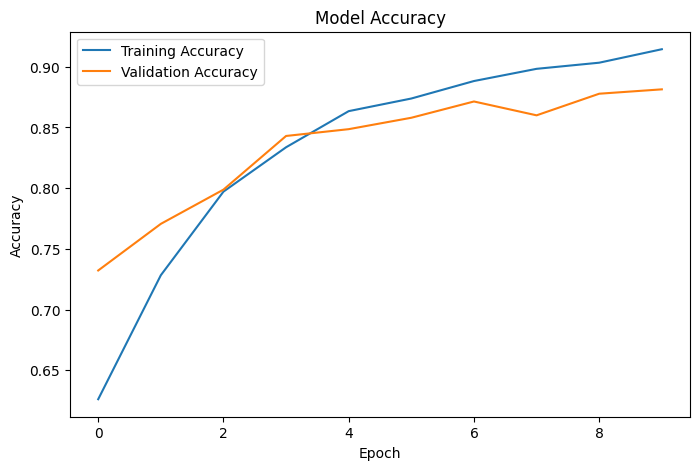

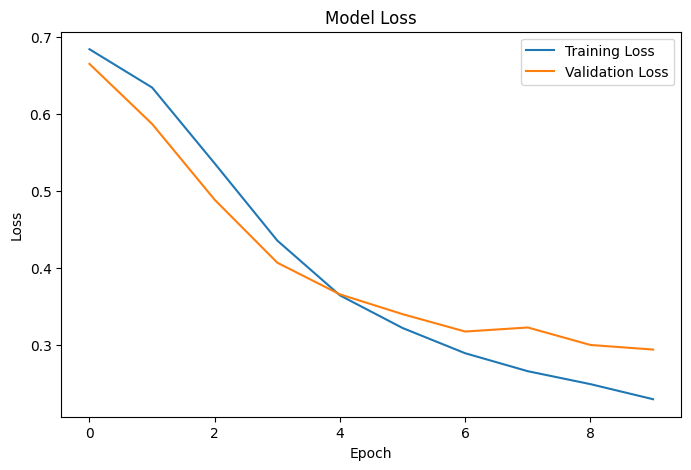

In [2]:
# ----------------------------------------------------------
# Word Embeddings using IMDB Dataset
# ----------------------------------------------------------

import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Load IMDB Dataset
# ----------------------------------------------------------

vocab_size = 10000   # Use top 10,000 frequent words

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

# ----------------------------------------------------------
# Pad sequences
# ----------------------------------------------------------

max_length = 200

X_train = tf.keras.preprocessing.sequence.pad_sequences(
    X_train,
    maxlen=max_length,
    padding='post'
)

X_test = tf.keras.preprocessing.sequence.pad_sequences(
    X_test,
    maxlen=max_length,
    padding='post'
)

# ----------------------------------------------------------
# Build Model
# ----------------------------------------------------------

model = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=32,
              input_length=max_length),

    GlobalAveragePooling1D(),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

# ----------------------------------------------------------
# Compile Model
# ----------------------------------------------------------

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ----------------------------------------------------------
# Train Model
# ----------------------------------------------------------

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=512,
    validation_split=0.2,
    verbose=1
)

# ----------------------------------------------------------
# Evaluate Model
# ----------------------------------------------------------

loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Loss :", loss)
print("Test Accuracy :", accuracy)

# ----------------------------------------------------------
# Plot Accuracy
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# ----------------------------------------------------------
# Plot Loss
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()
